# EDA instructions and notes
- Finds main columns and columns included in the dataset.
- Finds class imbalance.
- Each image's bounding box is declared by 3 doctors, find the disagreement of the annotations.
- Bounding box distribution.

# Presiquitesets (IDK HOW TO SPellL)
make sure to install the dataset as instructed in README.md

In [18]:
# libraries
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path


In [21]:
#from pathlib import Path
def find_project_root(start_path: Path) -> Path:
    """
    Tìm project root dựa trên thư mục .git hoặc README.md.
    """
    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        if (path / ".git").exists():
            return path

    raise FileNotFoundError(
        "Không tìm thấy project root. "
        "Hãy chắc chắn notebook đang được chạy bên trong repository."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("TRAIN_CSV    :", TRAIN_CSV)

PROJECT_ROOT : /home/culey/Developer/Projects/DATH-HK261-explainable-cxr
DATA_DIR     : /home/culey/Developer/Projects/DATH-HK261-explainable-cxr/data/raw
TRAIN_CSV    : /home/culey/Developer/Projects/DATH-HK261-explainable-cxr/data/raw/train.csv


In [5]:
df = pd.read_csv(TRAIN_CSV)
df.head()

,Unnamed: 0,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,raw_x_min,raw_x_max,raw_y_min,raw_y_max,raw_width,raw_height,scale_x,scale_y
0,0,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
1,1,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
2,2,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
3,3,183015e171f5159d7e60d43578632a3f,Aortic enlargement,0,R8,567.0,295.0,671.0,417.0,1134.0,1342.0,721.0,1019.0,2048.0,2500.0,0.500000,0.409600
4,4,183015e171f5159d7e60d43578632a3f,Pleural thickening,11,R9,58.0,794.0,116.0,851.0,117.0,232.0,1938.0,2077.0,2048.0,2500.0,0.500000,0.409600


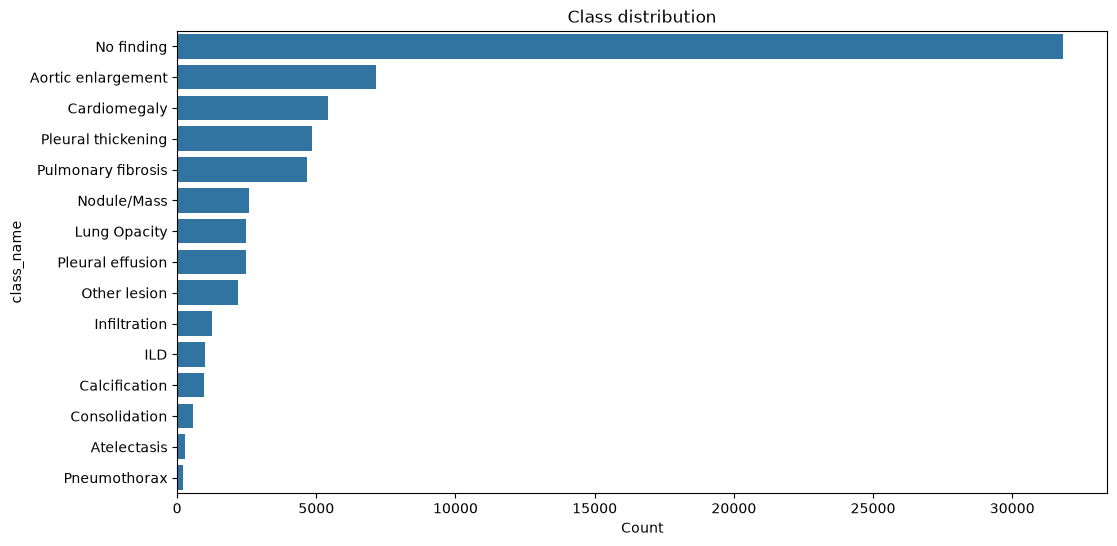

In [6]:
plt.figure(figsize=(12, 6))
class_counts = df["class_name"].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index)
plt.title("Class distribution")
plt.xlabel("Count")
plt.show()

In [7]:
df.isna().sum() # Okay so only x,y min-maxes have NaN values, now lets check if they have relation with no finding class

Unnamed: 0        0
image_id          0
class_name        0
class_id          0
rad_id            0
x_min         31818
y_min         31818
x_max         31818
y_max         31818
raw_x_min     31818
raw_x_max     31818
raw_y_min     31818
raw_y_max     31818
raw_width         0
raw_height        0
scale_x           0
scale_y           0
dtype: int64

In the result up there, "No finding" made a huge percentage on the distribution.

Now, we find the doctors' annotation from R1-R17.
- Radiologist ID (Rxx): an ID represent a doctor identity, like, who is responsible for the labeling of a specific image in the dataset.
- This is crucial for: Annotator bias and labeling noises

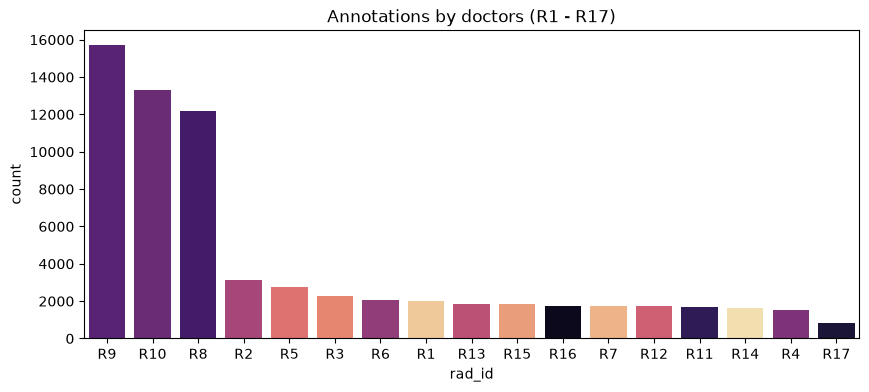

In [8]:
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df, 
    x="rad_id",
    hue="rad_id",
    legend=False, 
    order=df["rad_id"].value_counts().index, 
    palette="magma"
)
plt.title("Annotations by doctors (R1 - R17)")
plt.show()

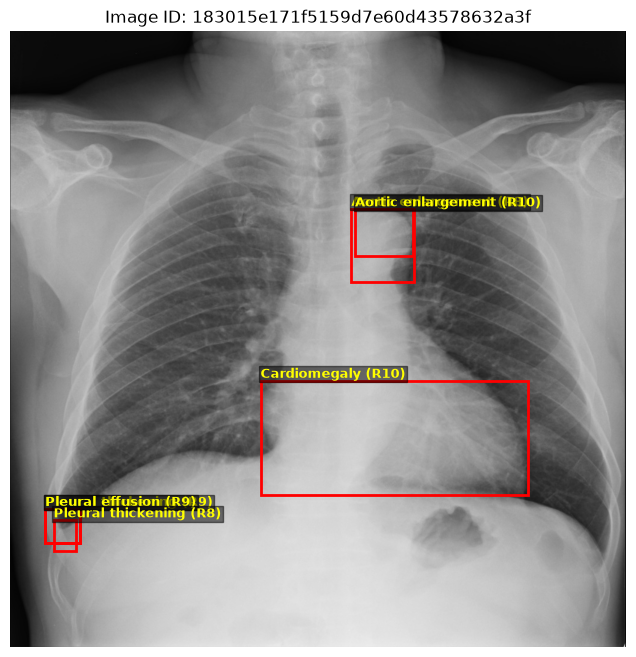

In [9]:
# function to display a specific image, with bounding boxes
def plot_cxr_img(image_id, df, img_folder_dir):
    boxes = df[df["image_id"] == image_id]
    img_dir = os.path.join(img_folder_dir, f'{image_id}.jpg')
    img = cv2.imread(img_dir)
    if img is None:
        print(f"[ERROR] Image not found: {image_id}.jpg")
        return

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    for _, row in boxes.iterrows():
        if row["class_id"] == 14:
            continue
        
        x_min, y_min = row["x_min"], row["y_min"]
        w = row["x_max"] - row["x_min"]
        h = row["y_max"] - row["y_min"]

        rect = patches.Rectangle(
            (x_min, y_min),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x_min,
            max(0, y_min - 5),
            f"{row['class_name']} ({row['rad_id']})",
            color="yellow",
            fontsize=9,
            weight="bold",
            bbox=dict(facecolor="black", alpha=0.5, pad=1),
        )

    plt.title(f"Image ID: {image_id}")
    plt.axis("off")
    plt.show()

abnormal_samples = df[df["class_id"] != 14]["image_id"].values
if len(abnormal_samples) > 0:
    plot_cxr_img(abnormal_samples[0], df, TRAIN_DIRECTORY)

# PROBLEM 1: Local Labels vs Global Labels.
- Local label: samples that have bounding boxes.
-> Contribute to Localization task.
- Global labels: samples that doesn't have bounding box.
-> Contribute to Classification task.

Now we need to find WHICH class actually have meaning to the localization loss. Currently, classes are not categorized into which image have bounding box and which doesn't have bounding box. 

Meanwhile, bounding-box classes have meaning on the Localization problem (RQ1: Does better classification imply better localization?).

This doesn't state that no-bounding box images are worthless, it just state that we need to categorize this to support the RQ evaluation only.
In fact, no-bounding box images would still be used in the Classification task of the backbones.

In [10]:
# TODO PRBL1

LOCAL_LABELS = [
    "Aortic enlargement", "Atelectasis", "Calcification", "Cardiomegaly", 
    "Clavicle fracture", "Consolidation", "Edema", "Emphysema", 
    "Enlarged PA", "Extramedullary hematopoiesis", "Fibrosis", "Hemidiaphragm elevation", 
    "Infiltration", "Lung cavity", "Lung cyst", "Lung opacity", 
    "Mediastinal shift", "Nodule/Mass", "Pleural effusion", "Pleural thickening", 
    "Pneumothorax", "Rib fracture"
]

GLOBAL_LABELS = [
    "COPD", "Lung tumor", "Pneumonia", "Tuberculosis", 
    "Other diseases", "No finding"
]

df_local = df[df["class_name"].isin(LOCAL_LABELS)].copy()
df_global = df[df["class_name"].isin(GLOBAL_LABELS)].copy()

print(f"Total dataset records: {len(df)}")
print(f"Number of records belonging to 22 Local Labels (with bbox): {len(df_local)}")
print(f"Number of records belonging to 6 Global Labels: {len(df_global)}")

missing_box_local = df_local["x_min"].isna().sum()
print(f"Number of local label records missing bounding box information: {missing_box_local}")

having_box_global = df_global["x_min"].notna().sum()
print(f"Number of global label records having bounding box information: {having_box_global}")

Total dataset records: 67914
Number of records belonging to 22 Local Labels (with bbox): 25755
Number of records belonging to 6 Global Labels: 31818
Number of local label records missing bounding box information: 0
Number of global label records having bounding box information: 0


/tmp/ipykernel_35365/1400020678.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


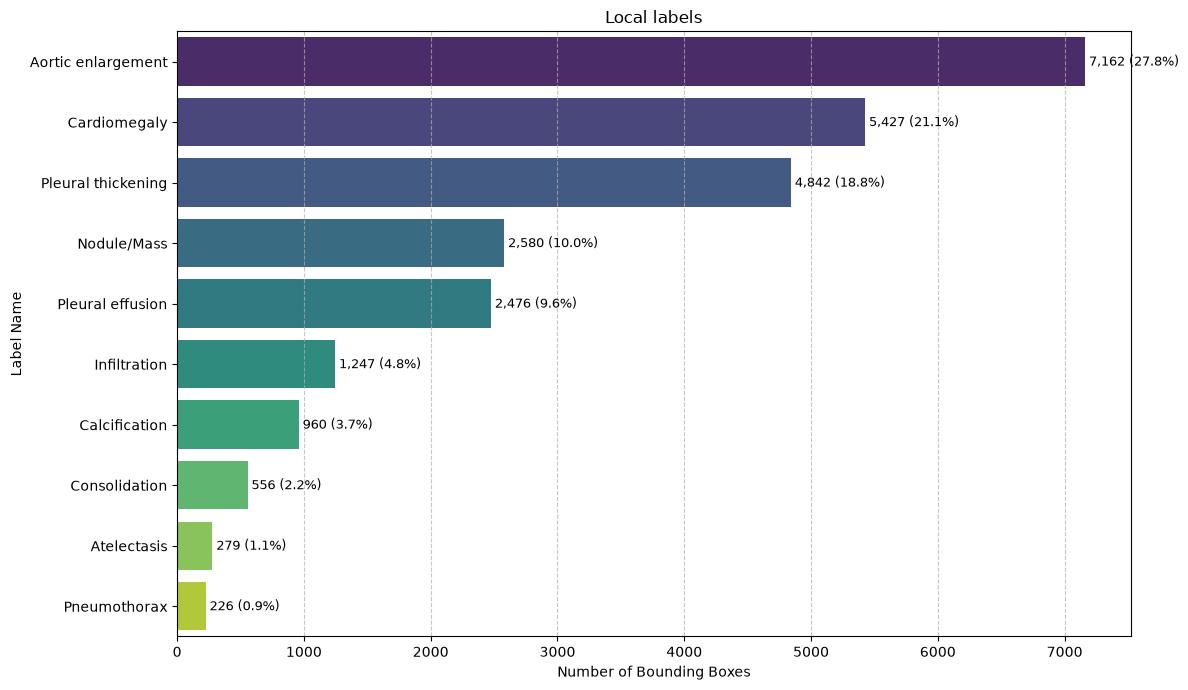

In [11]:
# frequency distribution of local labels
local_counts = df_local["class_name"].value_counts().reset_index()
local_counts.columns = ["class_name", "box_count"]
local_counts["percentage (%)"] = (local_counts["box_count"] / len(df_local)) * 100

plt.figure(figsize=(12, 7))
sns.barplot(
    data=local_counts, 
    x="box_count", 
    y="class_name", 
    palette="viridis"
)
plt.title("Local labels")
plt.xlabel("Number of Bounding Boxes")
plt.ylabel("Label Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)

for idx, row in local_counts.iterrows():
    plt.text(
        row["box_count"] + 30, idx, 
        f"{row['box_count']:,} ({row['percentage (%)']:.1f}%)", 
        va='center', 
        fontsize=9
    ) # this add numbers to plot

plt.tight_layout()
plt.show()

# PROBLEM 2: Inter-observer Disagreement - the disagreement in bounding box between doctors.
- Each image is classified and annotated by 3 different doctors.
- Measure: Agreement and Disagreement rate.
- When 2-3 doctors agree, what is the mismatch in the bounding box ? (IoU between doctors)

From there, we induce the consensus rule to choose whether annotator is okay when disagreement between these doctors is high.


Agreement distribution by class (Top 8 classes):


/tmp/ipykernel_35365/72885681.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vote_summary.index, y=vote_summary.values, palette='Blues_d')


doctor_votes,1,2,3
class_name,,,
Aortic enlargement,23.51,19.63,56.86
Calcification,60.84,26.55,12.61
Cardiomegaly,21.00,22.61,56.39
Consolidation,65.72,25.50,8.78
Infiltration,60.03,25.12,14.85
Nodule/Mass,50.97,27.12,21.91
Pleural effusion,38.57,18.90,42.54
Pleural thickening,55.48,26.10,18.43


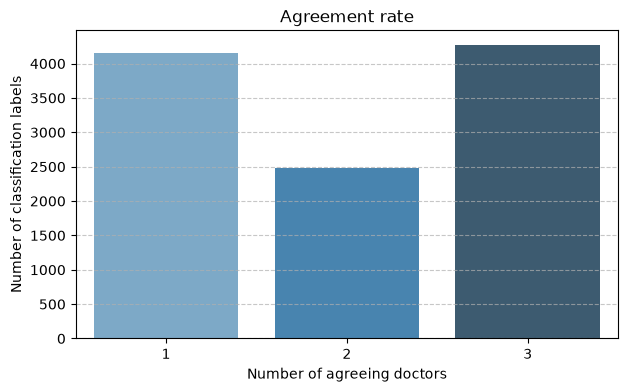

In [12]:
# TODO prbl2
# NOTE: Following code in this cell is used for CLASSIFICATION label agreement, \
# not LOCALIZATION BOUNDING BOX agreement
df_findings = df_local.dropna(subset=['x_min', 'y_min', 'x_max', 'y_max']).copy()

doctor_agreement = (
    df_findings.groupby(['image_id', 'class_name'])['rad_id']
    .nunique()
    .reset_index(name='doctor_votes')
) # unique rad_id for each (image_id, class_name)

# now we find if doctors agree, and what is the distribution of votes for each finding
vote_summary = doctor_agreement['doctor_votes'].value_counts().sort_index() 

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=vote_summary.index, y=vote_summary.values, palette='Blues_d')
plt.title("Agreement rate")
plt.xlabel("Number of agreeing doctors")
plt.ylabel("Number of classification labels")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# EXAMPLE: use for 8 most common local classes
top8_classes = local_counts.head(8)['class_name'].tolist()
print("\nAgreement distribution by class (Top 8 classes):")
agreement_pivot = pd.crosstab(
    doctor_agreement[doctor_agreement['class_name'].isin(top8_classes)]['class_name'],
    doctor_agreement['doctor_votes'],
    normalize='index'
) * 100
display(agreement_pivot.round(2))

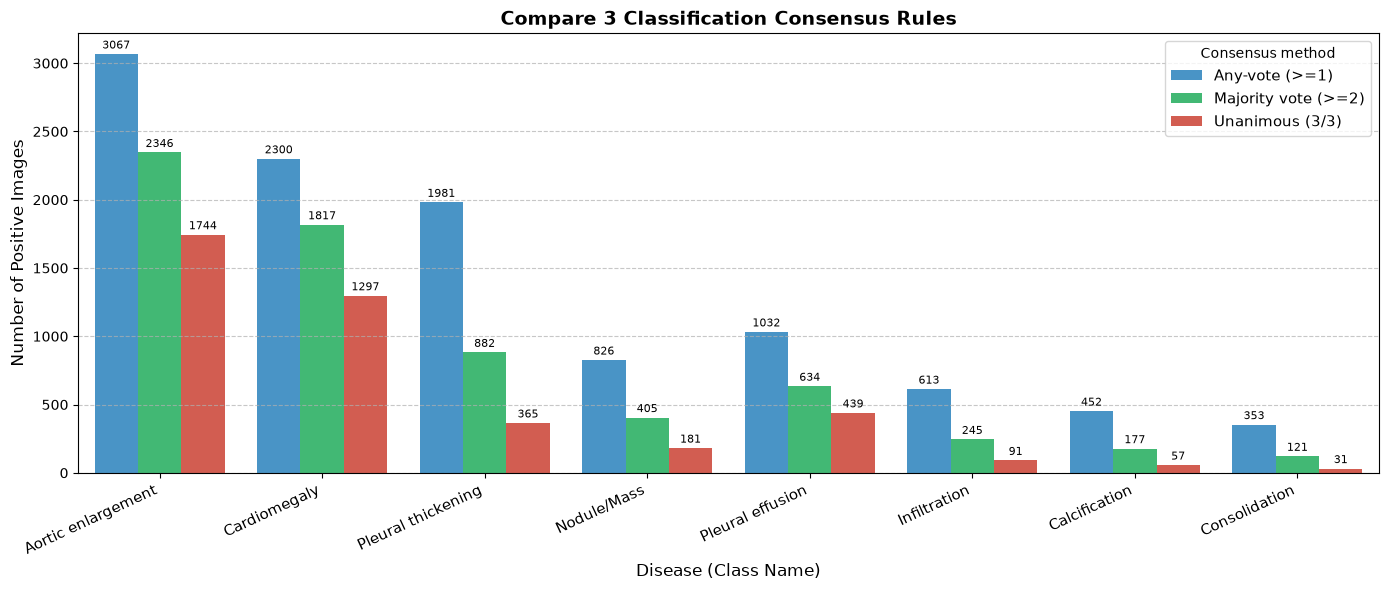

,Class,Any-vote (>=1),Majority vote (>=2),Majority vote (%),Unanimous (3/3),Unanimous (%)
0,Aortic enlargement,3067,2346,76.5,1744,56.9
1,Cardiomegaly,2300,1817,79.0,1297,56.4
2,Pleural thickening,1981,882,44.5,365,18.4
3,Nodule/Mass,826,405,49.0,181,21.9
4,Pleural effusion,1032,634,61.4,439,42.5
5,Infiltration,613,245,40.0,91,14.8
6,Calcification,452,177,39.2,57,12.6
7,Consolidation,353,121,34.3,31,8.8


In [13]:
agreement_counts = doctor_agreement.copy()

# EXAMPLE: use for 8 most common local classes
top_classes = local_counts.head(8)['class_name'].tolist()
filtered_agreements = agreement_counts[agreement_counts['class_name'].isin(top_classes)]

# positive sample counts for each class and each voting rule
comparison_data = []
for cname in top_classes:
    c_df = filtered_agreements[filtered_agreements['class_name'] == cname]
    
    any_vote = (c_df['doctor_votes'] >= 1).sum()       # Any-vote (>= 1)
    majority_vote = (c_df['doctor_votes'] >= 2).sum()  # Majority vote (>= 2)
    unanimous_vote = (c_df['doctor_votes'] == 3).sum() # Unanimous vote (3/3)
    
    comparison_data.append({
        'Class': cname,
        'Any-vote (>=1)': any_vote,
        'Majority vote (>=2)': majority_vote,
        'Unanimous (3/3)': unanimous_vote,
        'Majority vote (%)': (majority_vote / any_vote) * 100 if any_vote > 0 else 0,
        'Unanimous (%)': (unanimous_vote / any_vote) * 100 if any_vote > 0 else 0
    })

df_comparison = pd.DataFrame(comparison_data)

# plot per consensus method
df_plot = df_comparison.melt(
    id_vars=['Class'], 
    value_vars=['Any-vote (>=1)', 'Majority vote (>=2)', 'Unanimous (3/3)'],
    var_name='Rule', 
    value_name='Positive Samples'
)

plt.figure(figsize=(14, 6))
palette = {'Any-vote (>=1)': '#3498db', 'Majority vote (>=2)': '#2ecc71', 'Unanimous (3/3)': '#e74c3c'}

ax = sns.barplot(data=df_plot, x='Class', y='Positive Samples', hue='Rule', palette=palette)
plt.title("Compare 3 Classification Consensus Rules", fontsize=14, fontweight='bold')
plt.xlabel("Disease (Class Name)", fontsize=12)
plt.ylabel("Number of Positive Images", fontsize=12)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Consensus method", fontsize=11)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f"{int(height)}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# 4. detailed table of retention rates
from IPython.display import display
display(df_comparison[['Class', 'Any-vote (>=1)', 'Majority vote (>=2)', 'Majority vote (%)', 'Unanimous (3/3)', 'Unanimous (%)']].round(1))

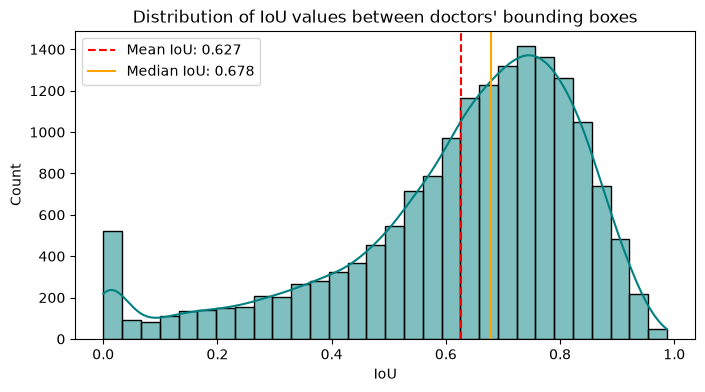

In [14]:
# iou metric
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (box1[2] - box1[0]) * (box1[3] - box1[1])
    boxBArea = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou


# with IoU metric, we can now find the agreement between doctors.
# agreement -> IoU agreement, which is distribution of IoU values for the bounding box

doctor_ious = []
zero_iou_count = 0
grouped = df_findings.groupby(['image_id', 'class_name'])
for (img_id, cname), group in grouped:
    rad_boxes = [
            (row['rad_id'], [row['x_min'], row['y_min'], row['x_max'], row['y_max']])
            for _, row in group.iterrows()
        ]
    for i in range(len(rad_boxes)):
            for j in range(i + 1, len(rad_boxes)):
                rad_i, box_i = rad_boxes[i]
                rad_j, box_j = rad_boxes[j]
                
                # Bỏ qua nếu là 2 box do CÙNG MỘT bác sĩ vẽ trên ảnh
                if rad_i == rad_j:
                    continue
                
                iou = compute_iou(box_i, box_j)
                
                if iou > 0:
                    doctor_ious.append(iou)
                else:
                    zero_iou_count += 1

    
plt.figure(figsize=(8, 4))
sns.histplot(doctor_ious, bins=30, kde=True, color='teal')
plt.axvline(np.mean(doctor_ious), color='red', linestyle='--', label=f'Mean IoU: {np.mean(doctor_ious):.3f}')
plt.axvline(np.median(doctor_ious), color='orange', linestyle='-', label=f'Median IoU: {np.median(doctor_ious):.3f}')
plt.title("Distribution of IoU values between doctors' bounding boxes")
plt.xlabel('IoU')
plt.legend()
plt.show()



# PROBLEM 3: Multi-label
One person can catch with 2 or more diseases
- Each image id will have how much diseases ?
- Find co-occurence heatmap, to see which diseases are often go together.
- Find pos_weight N_neg/N_pos of each class when we group by image id.


In [15]:
# TODO prbl3

# PROBLEM 4: Bounding Box distribution.
- Find relative area of bounding box compare to the image size.
- For each disease class, analyze that value.


In [16]:
# TODO prbl4

# PROBLEM 5: Consensus visualization
- Bounding box of each doctor
- After-consensus ruling bounding box.
- Ground-truth binary masks G_c 224x224 

In [17]:
# TODO